# Gradientinis nusileidimas

Aproksimuokime trigonometrinę funkciją $y = f(x) = sin(x)$ polinomine funkcija $\hat{y} = \hat{f}(x) = a + bx + cx^2 + dx^3$.

Nuostolių funkcija: $loss = (\hat{y} - y)^2 = (a + bx + cx^2 + dx^3 - sin(x))^2 $

Parametrų dalinės išvestinės x atžvilgiu:  
$\frac{\partial loss}{\partial a} = 2 (\hat{y} - y) \cdot (1)$  
$\frac{\partial loss}{\partial b} = 2 (\hat{y} - y) \cdot (x) $  
$\frac{\partial loss}{\partial c} = 2 (\hat{y} - y) \cdot (x^2) $  
$\frac{\partial loss}{\partial d} = 2 (\hat{y} - y) \cdot (x^3) $

## Šiek tiek matematikos


Funkciją $\hat{f}(x)$ geriau būtų užrašyti taip:

$\hat{f}(x | \theta) = a + bx + cx^2 + dx^3$, su parametrais $\theta = (a, b, c, d)$.

## Duomenų generavimas

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.linspace(-np.pi, np.pi, 1000)
y = np.sin(x)

## Modelio sukūrimas

In [6]:
def create_model():
  a = np.random.randn()
  b = np.random.randn()
  c = np.random.randn()
  d = np.random.randn()

  return (a, b, c, d)

def predict(model, x):
  a, b, c, d = model
  return a + b * x + c * x**2 + d * x**3

## Išvestinių skaičiavimas

In [4]:
def grad(x, y, y_pred):
  a_grad = np.mean(2 * (y_pred - y) * 1)
  b_grad = np.mean(2 * (y_pred - y) * x)
  c_grad = np.mean(2 * (y_pred - y) * x**2)
  d_grad = np.mean(2 * (y_pred - y) * x**3)

  return (a_grad, b_grad, c_grad, d_grad)

## Mokymo ciklas

In [7]:
learning_rate = 1e-3

model = create_model()
for i in range(2000):
  y_pred = predict(model, x)

  loss = np.mean((y_pred - y)**2)
  if i % 200 == 0:
    print(f'Iteration: {i}, Loss: {loss}')

  a, b, c, d = model
  a_grad, b_grad, c_grad, d_grad = grad(x, y, y_pred)
  a -= a_grad * learning_rate
  b -= b_grad * learning_rate
  c -= c_grad * learning_rate
  d -= d_grad * learning_rate

  model = (a, b, c, d)

print(f'Model: {a} + {b}x + {c}x^2 + {d}x^3')

Iteration: 0, Loss: 317.189044245575
Iteration: 200, Loss: 0.2916303163047929
Iteration: 400, Loss: 0.20637074484043427
Iteration: 600, Loss: 0.1464774483307292
Iteration: 800, Loss: 0.10438455341691784
Iteration: 1000, Loss: 0.0747893906090755
Iteration: 1200, Loss: 0.053973052474941385
Iteration: 1400, Loss: 0.03932599829311841
Iteration: 1600, Loss: 0.029016211646680973
Iteration: 1800, Loss: 0.021756924550404035
Model: 0.16103368544976454 + 0.8204801042668477x + -0.027752032487876672x^2 + -0.08815502202184415x^3


## Modelio testavimas

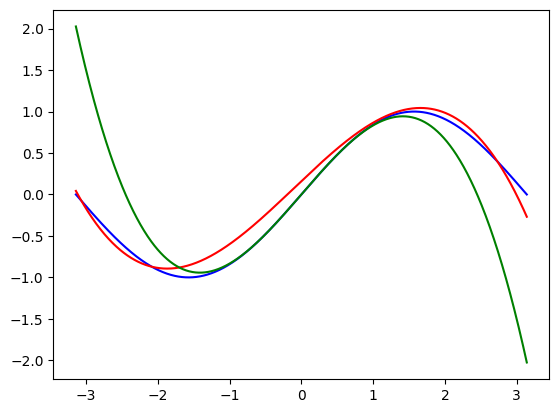

In [9]:
y_pred = predict(model, x)

plt.plot(x, y, 'b-')
plt.plot(x, y_pred, 'r-')

y_taylor = x - (x**3)/6
plt.plot(x, y_taylor, 'g-')

## Modelio palyginimas su analitiniu sprendiniu

$f(x) = sin(x)$ aproksimuota Teiloro eilute:

$f(x) \approx 0 + 1x + 0x^2 + \frac{-1}{3!}x^3 = x - \frac{1}{6}x^3$